
<img src="https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/img/ods_stickers.jpg">

## <center> [mlcourse.ai](https://mlcourse.ai) – открытый курс OpenDataScience по машинному обучению
    
Автор материала: Юрий Кашницкий (@yorko в Slack ODS). Материал распространяется на условиях лицензии [Creative Commons CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/). Можно использовать в любых целях (редактировать, поправлять и брать за основу), кроме коммерческих, но с обязательным упоминанием автора материала.

# <center>Домашнее задание № 10 (демо)
## <center> Прогнозирование задержек вылетов

Ваша задача – побить единственный бенчмарк в [соревновании](https://www.kaggle.com/c/flight-delays-2017) на Kaggle Inclass. Подробных инструкций не будет, будет только тезисно описано, как получен этот бенчмарк. Конечно, с помощью Xgboost. Надеюсь, на данном этапе курса вам достаточно бросить полтора взгляда на данные, чтоб понять, что это тот тип задачи, в которой затащит Xgboost. Но проверьте еще Catboost.

<img src="https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/img/xgboost_meme.jpg" width=40% />

In [ ]:
!pip install -q catboost optuna optuna-integration dython shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 18.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

from collections import Counter

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.utils import class_weight
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold

from catboost import CatBoostClassifier

import optuna
from optuna.integration import OptunaSearchCV
from dython.nominal import associations

import shap

In [ ]:
pd.set_option('future.no_silent_downcasting', True)
sns.set_style('dark')

In [ ]:
train = pd.read_csv('flight_delays_train.csv')
test = pd.read_csv('flight_delays_test.csv')

In [ ]:
train = train.rename(columns={'DayofMonth': 'DayOfMonth'})
test = test.rename(columns={'DayofMonth': 'DayOfMonth'})

In [ ]:
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


In [ ]:
test.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance
0,c-7,c-25,c-3,615,YV,MRY,PHX,598
1,c-4,c-17,c-2,739,WN,LAS,HOU,1235
2,c-12,c-2,c-7,651,MQ,GSP,ORD,577
3,c-3,c-25,c-7,1614,WN,BWI,MHT,377
4,c-6,c-6,c-3,1505,UA,ORD,STL,258


### Анализ данных

Проверим, нет ли в данных отсутствующих значений

In [ ]:
print(f'В тренировочных данных количество пропусков: {train.isna().sum().sum()}')
print(f'В тестовых данных количество пропусков: {test.isna().sum().sum()}')

В тренировочных данных количество пропусков: 0
В тестовых данных количество пропусков: 0


Отлично, их нет

Посмотрим на дизбаланс классов

In [ ]:
train['dep_delayed_15min'].value_counts()

,count
dep_delayed_15min,
N,80956
Y,19044


Как видно, данные сильно дизбалансированы (объектов 0 класса более чем в 4 раза больше, чем 1). Это надо будет учесть при обучении моделей

Посмотрим на признак времени вылета

In [ ]:
train['DepTime'].value_counts().sort_index()

,count
DepTime,
1,7
2,9
3,4
4,4
5,11
...,...
2505,1
2514,1
2522,1


Замечаем, что есть значения, большие, чем 2359, что является ошибкой, так как в сутках только 24 часа, далее посмотрим, сколько таких записей вообще есть в тренировочных данных

In [ ]:
train[train['DepTime'] > 2359].shape[0]

29

Сделаем следующее - возьмём остаток времени вылета от 2400, таким образом все значения будут от 0 до 2359. Проделаем это также и с тестовой выборкой

In [ ]:
train['DepTime'] = train['DepTime'] % 2400
test['DepTime'] = test['DepTime'] % 2400

Добавим в тренировочные данные числовые признаки месяца, дня месяца и дня недели (для удобства визуализации)

In [ ]:
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,DFW,732,N
1,c-4,c-20,c-3,1548,US,PIT,MCO,834,N
2,c-9,c-2,c-5,1422,XE,RDU,CLE,416,N
3,c-11,c-25,c-6,1015,OO,DEN,MEM,872,N
4,c-10,c-7,c-6,1828,WN,MDW,OMA,423,Y


In [ ]:
train = train.assign(
    NumberMonth=train['Month'].str[2:].astype(int),
    NumberDayOfMonth=train['DayOfMonth'].str[2:].astype(int),
    NumberDayOfWeek=train['DayOfWeek'].str[2:].astype(int)
)

In [ ]:
def plot_histograms(
    column, plotbars=True, figsize=(15, 8), hue_order=['N', 'Y'],
    countpalette=['blue', 'orange'], barpalette='magma', fontsize=10,
    rotation=0, fmt='%.3f'
):
    _, axes = plt.subplots(nrows=2, ncols=1, figsize=figsize)

    sns.countplot(
        data=train.sort_values(by=column), x=column,
        hue='dep_delayed_15min', hue_order=hue_order,
        palette=countpalette, ax=axes[0]
    )
    if plotbars:
        for container in axes[0].containers:
            axes[0].bar_label(container, rotation=rotation, fontsize=fontsize)
    axes[0].set_title('Количество задержанных и незадержанных рейсов')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
    sns.move_legend(axes[0], 'upper left', bbox_to_anchor=(1, 1))

    sns.barplot(
        (
            train[train['dep_delayed_15min'] == 'Y'][column].value_counts() /
            train[column].value_counts()
        ).sort_index(), palette=barpalette, ax=axes[1]
    )
    if plotbars:
        for container in axes[1].containers:
            axes[1].bar_label(container, fmt=fmt)
    axes[1].set_title('Процент задержанных рейсов')
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')

    plt.tight_layout()
    plt.show()

Исследуем гистограммы числа месяца

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


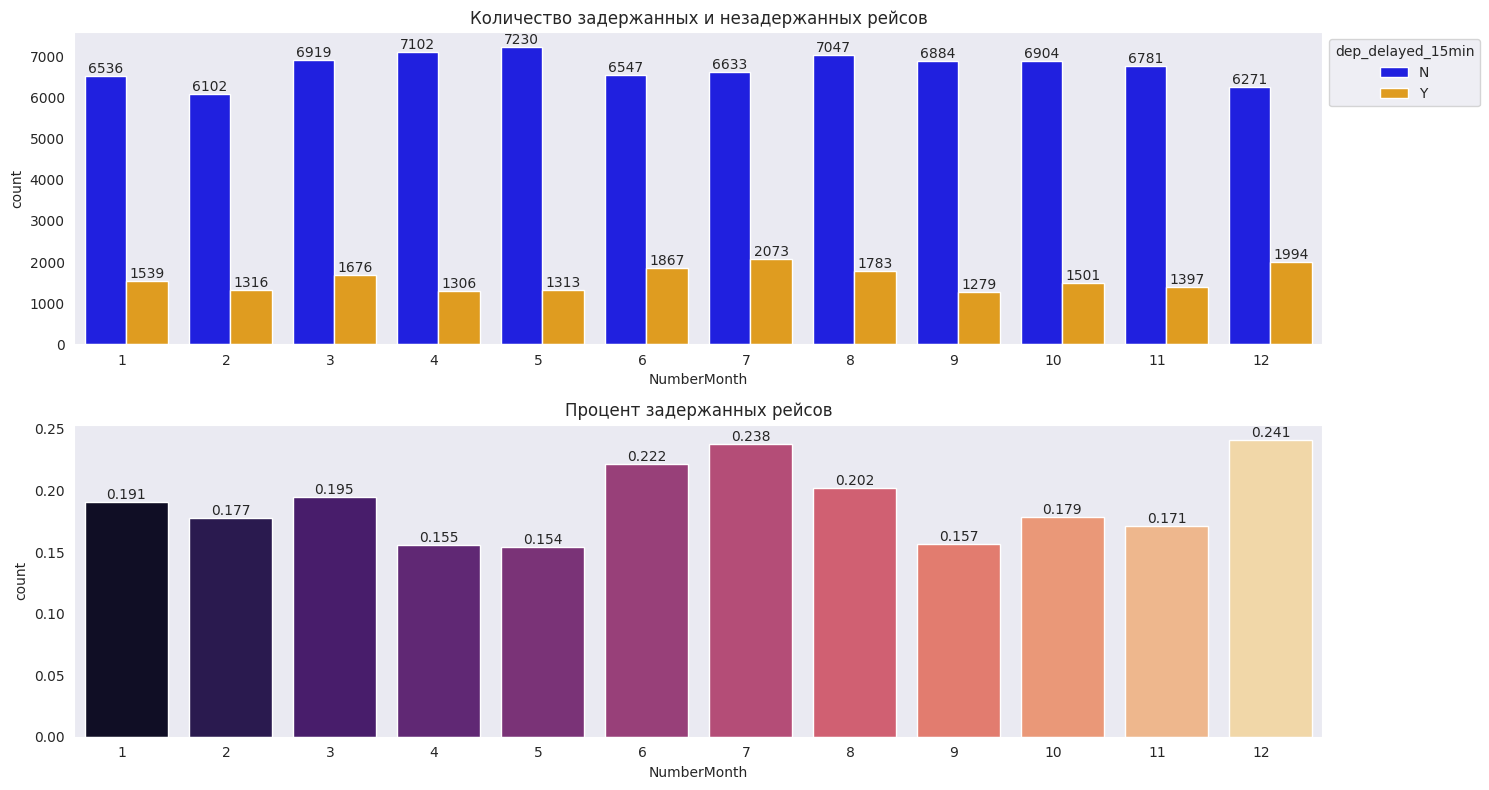

In [ ]:
plot_histograms('NumberMonth')

Видим, что в каждом месте количество незадержанных рейсов кратно превышает число задержанных. Однако важно учитывать не только количество, но и процентное содержание задержанных рейсов. Например, самое большое их количество в июле (2073), но процентное содержание больше всего в декабре (~0.2413)

В целом, это важный признак для будущих моделей, поэтому его следует оставить

Теперь рассмотрим гистограммы для признака дня недели

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


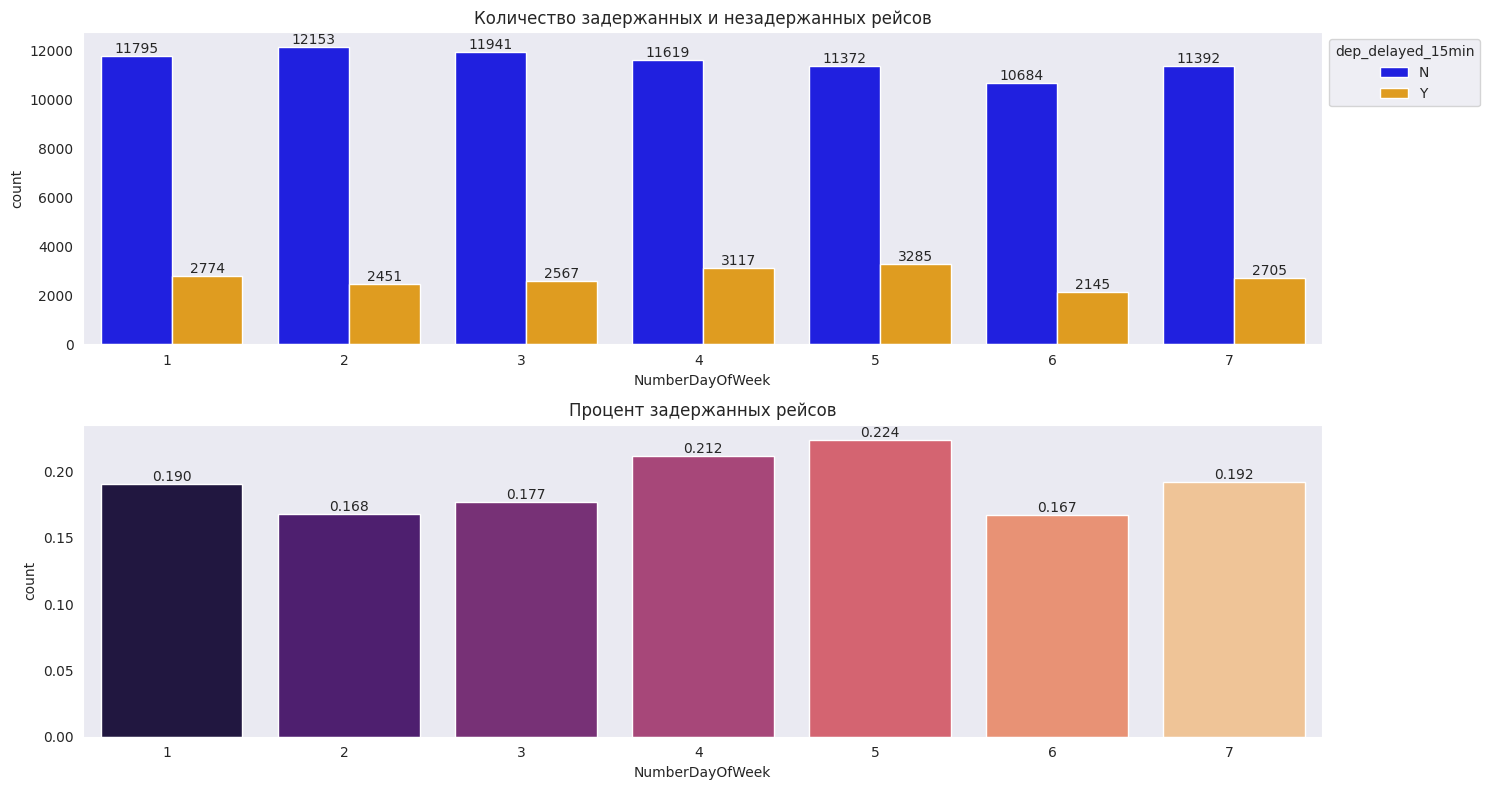

In [ ]:
plot_histograms('NumberDayOfWeek')

А у признака дня недели большее количество неотменённых рейсов почти всегда соотвествует большему их процентному содержанию (исключение составляет лишь случай понедельника и воскресенья), и этот признак следует сохранить, так как возможно на тестовой выборке будет наблюдаться та же самая зависимость

 Теперь пронаблюдаем гистограммы для дня месяца

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


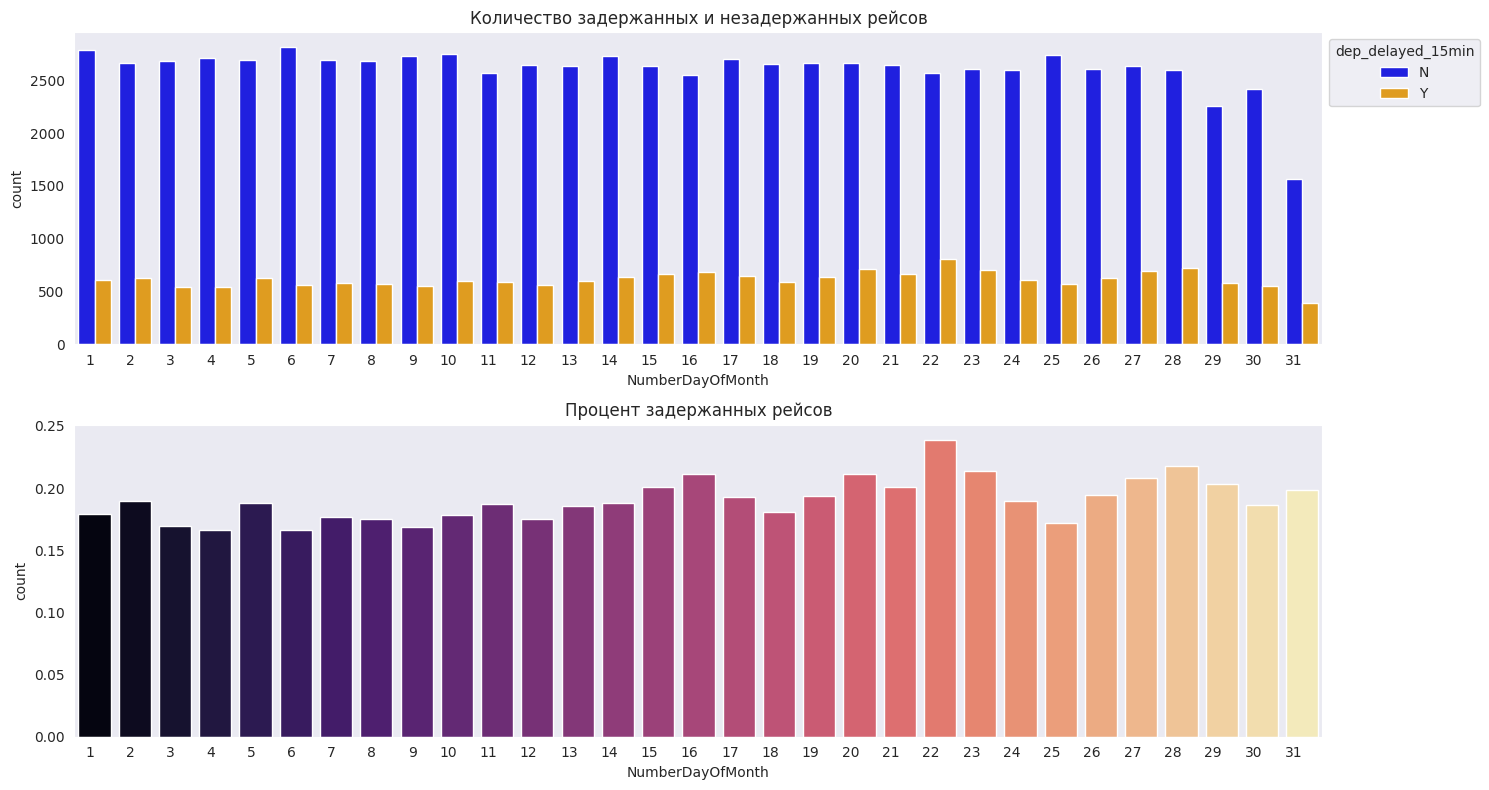

In [ ]:
plot_histograms('NumberDayOfMonth', plotbars=False)

Видим, что числам с 29 по 31 соответсвуют меньшие значения числа задержанных рейсов, но в процентном содержании они не являются экстремальными значениями. Также замечаем, что в процентном и количественном отношении больше всего рейсов было задержано 22 числа

Добавим эти же признаки в тестовую выборку

In [ ]:
train = train.drop(columns=['NumberMonth', 'NumberDayOfWeek', 'NumberDayOfMonth'])

In [ ]:
test.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,Dest,Distance
0,c-7,c-25,c-3,615,YV,MRY,PHX,598
1,c-4,c-17,c-2,739,WN,LAS,HOU,1235
2,c-12,c-2,c-7,651,MQ,GSP,ORD,577
3,c-3,c-25,c-7,1614,WN,BWI,MHT,377
4,c-6,c-6,c-3,1505,UA,ORD,STL,258


Затем посмотрим на гистограммы компании-перевозчика

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


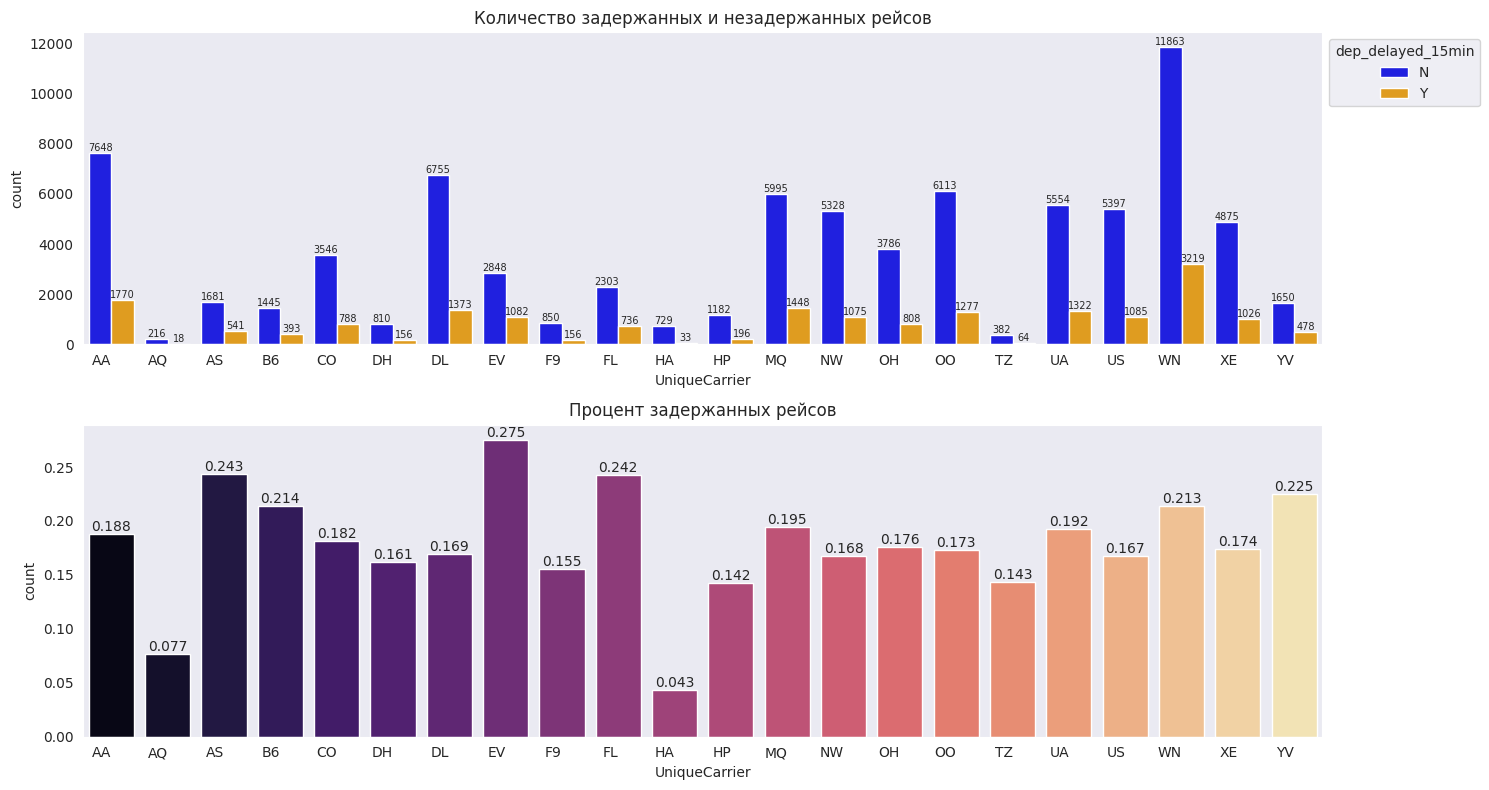

In [ ]:
plot_histograms('UniqueCarrier', fontsize=7)

А вот тут видно, заметен большой разброс как среди количественных, так и среди процентных значений. По количественному показателю худшей является авиакомпания WN, а по процентному - EV. Признак авиаперевозчика является очень важным для предсказани задержания рейса, поэтому его непременно следует оставить

Создадим ещё один признак - так как пунктов назначения и отправки достаточно много, то мы разделим их на неколько категорий по количеству отправленных/принятых рейсов. Причём границы категорий будут равномерно распределны в логарифмическом масштабе

In [ ]:
def get_airports(column, categories):
    train_flights, test_flights = pd.DataFrame(train[column].value_counts()), pd.DataFrame(test[column].value_counts())
    train_values, test_values = [], []
    borders = np.concatenate([np.array([0]), np.logspace(1, np.log10(6000), categories)])

    for i in range(1, borders.shape[0]):
        train_values.append(train_flights[(train_flights['count'] > borders[i - 1]) & (train_flights['count'] <= borders[i])].index)
        test_values.append(test_flights[(test_flights['count'] > borders[i - 1]) & (test_flights['count'] <= borders[i])].index)

    train_sizes = [value.shape[0] for value in train_values]
    test_sizes = [value.shape[0] for value in test_values]

    ax = sns.barplot(data=pd.DataFrame({
        'index': list(range(0, categories)) + list(range(0, categories)),
        'size': train_sizes + test_sizes,
        'label': ['train'] * categories + ['test'] * categories
    }), x='index', y='size', hue='label')

    ax.set_xlabel(column)
    for container in ax.containers:
        ax.bar_label(container)

    ax.set_ylabel('Airports')

    return train_values, test_values

Визуальным эмпирическим путём было выяснено, что лучше всего распределения нового признака на тренировочной и тестовой выборке совпадают, когда общее число категорий равняется 6

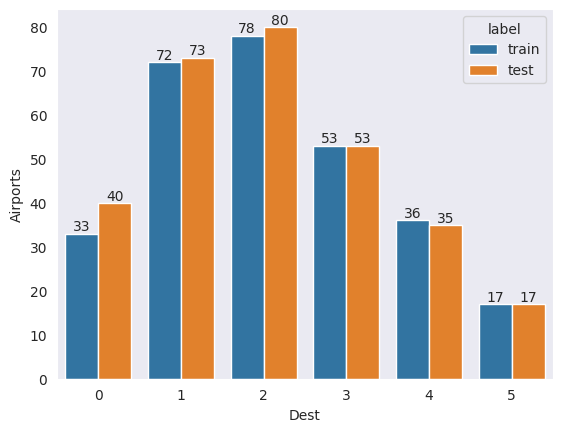

In [ ]:
train_dests, test_dests = get_airports('Dest', 6)

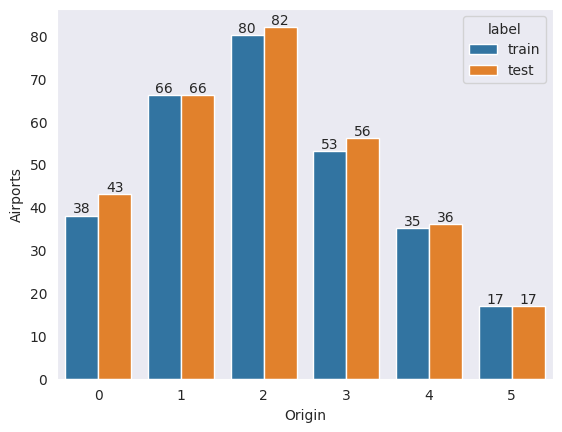

In [ ]:
train_origins, test_origins = get_airports('Origin', 6)

Этот признак можно сделать численным (как будто он был обработан label-encoder-ом), так как чем больше значение, тем большее число рейсов отправляет/принимает данный аэропорт

In [ ]:
def insert_and_full(df, column, values):
    df.insert(loc=df.columns.get_loc(column) + 1, column=column + 'Cat', value=0)
    for index in range(len(values)):
        df.loc[df[column].isin(values[index]), column + 'Cat'] = index
    return df

In [ ]:
train = insert_and_full(train, 'Origin', train_origins)
train = insert_and_full(train, 'Dest', train_dests)
test = insert_and_full(test, 'Origin', test_origins)
test = insert_and_full(test, 'Dest', test_dests)

In [ ]:
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,OriginCat,Dest,DestCat,Distance,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,5,DFW,5,732,N
1,c-4,c-20,c-3,1548,US,PIT,4,MCO,5,834,N
2,c-9,c-2,c-5,1422,XE,RDU,4,CLE,4,416,N
3,c-11,c-25,c-6,1015,OO,DEN,5,MEM,4,872,N
4,c-10,c-7,c-6,1828,WN,MDW,4,OMA,3,423,Y


In [ ]:
test.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,OriginCat,Dest,DestCat,Distance
0,c-7,c-25,c-3,615,YV,MRY,2,PHX,5,598
1,c-4,c-17,c-2,739,WN,LAS,5,HOU,4,1235
2,c-12,c-2,c-7,651,MQ,GSP,3,ORD,5,577
3,c-3,c-25,c-7,1614,WN,BWI,4,MHT,3,377
4,c-6,c-6,c-3,1505,UA,ORD,5,STL,4,258


Теперь посмотрим на плотноти распределения время вылета и расстояния в зависимости от того, был задержан рейс или нет

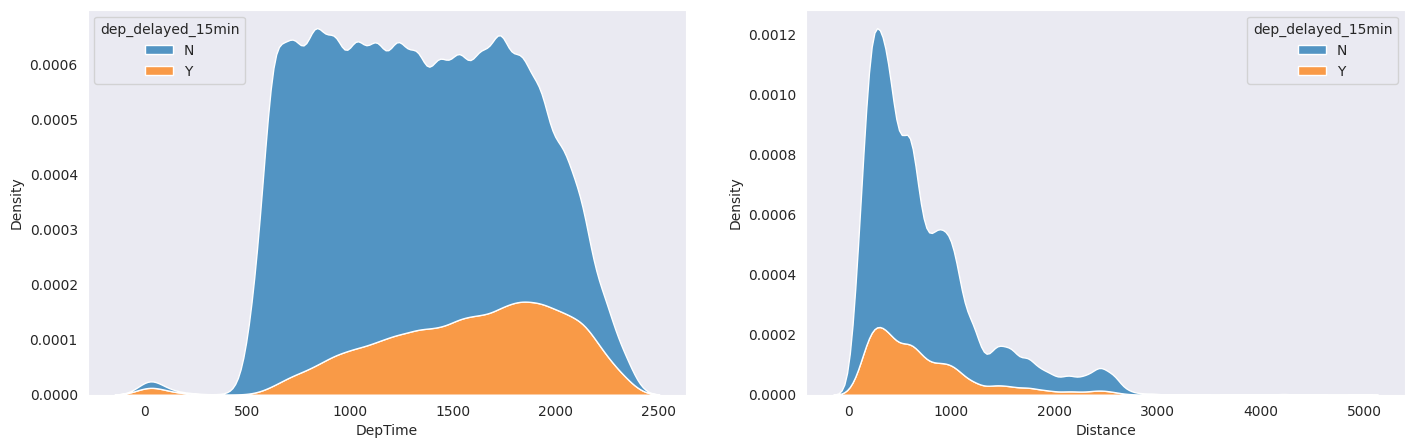

In [ ]:
_, ax = plt.subplots(nrows=1, ncols=2, figsize=(17, 5))
sns.kdeplot(data=train, x='DepTime', hue='dep_delayed_15min', multiple='stack', ax=ax[0])
sns.kdeplot(data=train, x='Distance', hue='dep_delayed_15min', multiple='stack', ax=ax[1])
plt.show()

Замечаем, что если у признака дистанции оба распределения смахивают на экспоненциальное, хоть и довольно сильно раличаются по форме, то вот у признака времени вылета незадержанные рейсы имеют форму равномерного распределения, а задержанные - скошенного вправо, то есть до определённого момента чем позже время вылета, тем больше вероятность задержки рейса

В данных нет довольно важного признака - его, думается мне, стоит добавить. Если подумать логически, то задержка рейса может зависеть не столько от аэропорта вылета или прилёта, сколько от их комбинации, то есть, попросту говоря, от рейса

In [ ]:
train.insert(train.shape[1] - 1, 'Route', train['Origin'] + ' - ' + train['Dest'])
test.insert(test.shape[1], 'Route', test['Origin'] + ' - ' + test['Dest'])

In [ ]:
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,OriginCat,Dest,DestCat,Distance,Route,dep_delayed_15min
0,c-8,c-21,c-7,1934,AA,ATL,5,DFW,5,732,ATL - DFW,N
1,c-4,c-20,c-3,1548,US,PIT,4,MCO,5,834,PIT - MCO,N
2,c-9,c-2,c-5,1422,XE,RDU,4,CLE,4,416,RDU - CLE,N
3,c-11,c-25,c-6,1015,OO,DEN,5,MEM,4,872,DEN - MEM,N
4,c-10,c-7,c-6,1828,WN,MDW,4,OMA,3,423,MDW - OMA,Y


In [ ]:
test.head()

,Month,DayOfMonth,DayOfWeek,DepTime,UniqueCarrier,Origin,OriginCat,Dest,DestCat,Distance,Route
0,c-7,c-25,c-3,615,YV,MRY,2,PHX,5,598,MRY - PHX
1,c-4,c-17,c-2,739,WN,LAS,5,HOU,4,1235,LAS - HOU
2,c-12,c-2,c-7,651,MQ,GSP,3,ORD,5,577,GSP - ORD
3,c-3,c-25,c-7,1614,WN,BWI,4,MHT,3,377,BWI - MHT
4,c-6,c-6,c-3,1505,UA,ORD,5,STL,4,258,ORD - STL


Сначала просто посмотрим на распределение количества полётов по маршрутам на тренировочной выборке (выведем топ-20 для незадержанных и задержанных рейсов)

In [ ]:
def plot_routes(
    value, title, ax, df=train, condition='dep_delayed_15min',
    column='Route', fontsize=8, rotation=90, most_common=20
):
    counter = Counter(df[df[condition] == value][column])
    routes, frequences = list(zip(*counter.most_common(most_common)))
    sns.barplot(x=routes, y=frequences, ax=ax)
    ax.bar_label(ax.containers[0], fontsize=fontsize)
    ax.set_xticklabels(labels=routes, rotation=rotation)
    ax.set_title(title)

/tmp/ipython-input-4247198834.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=routes, rotation=rotation)
/tmp/ipython-input-4247198834.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels=routes, rotation=rotation)


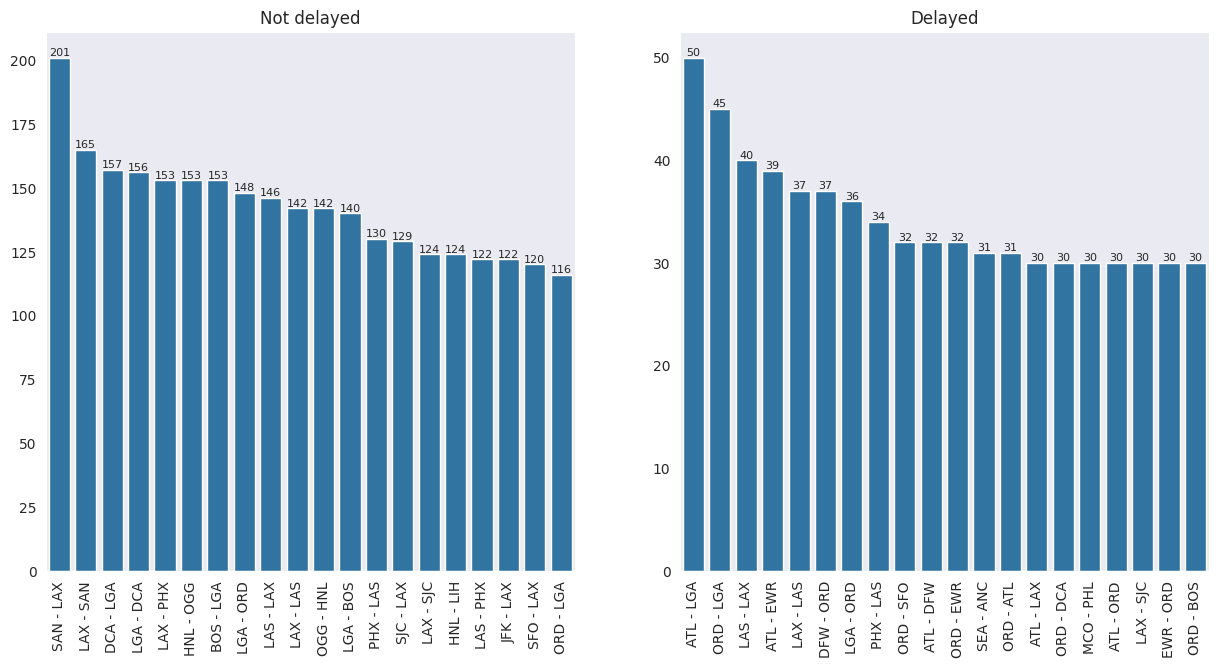

In [ ]:
_, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))
plot_routes('N', 'Not delayed', axes[0])
plot_routes('Y', 'Delayed', axes[1])
plt.show()

Видим, что пересечений рейсов для топ-20 нет, то есть если по маршруту много незадержанных рейсов, то мало задержанных и наоборот

Добавим новый признак, равный часу отлёта

In [ ]:
index = train.columns.get_loc('DepTime')
for df in train, test:
    df.insert(index + 1, 'DepHour', df['DepTime'] // 100)

Посмотрим на статистику задержанных рейсов в зависимости от часа вылета

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


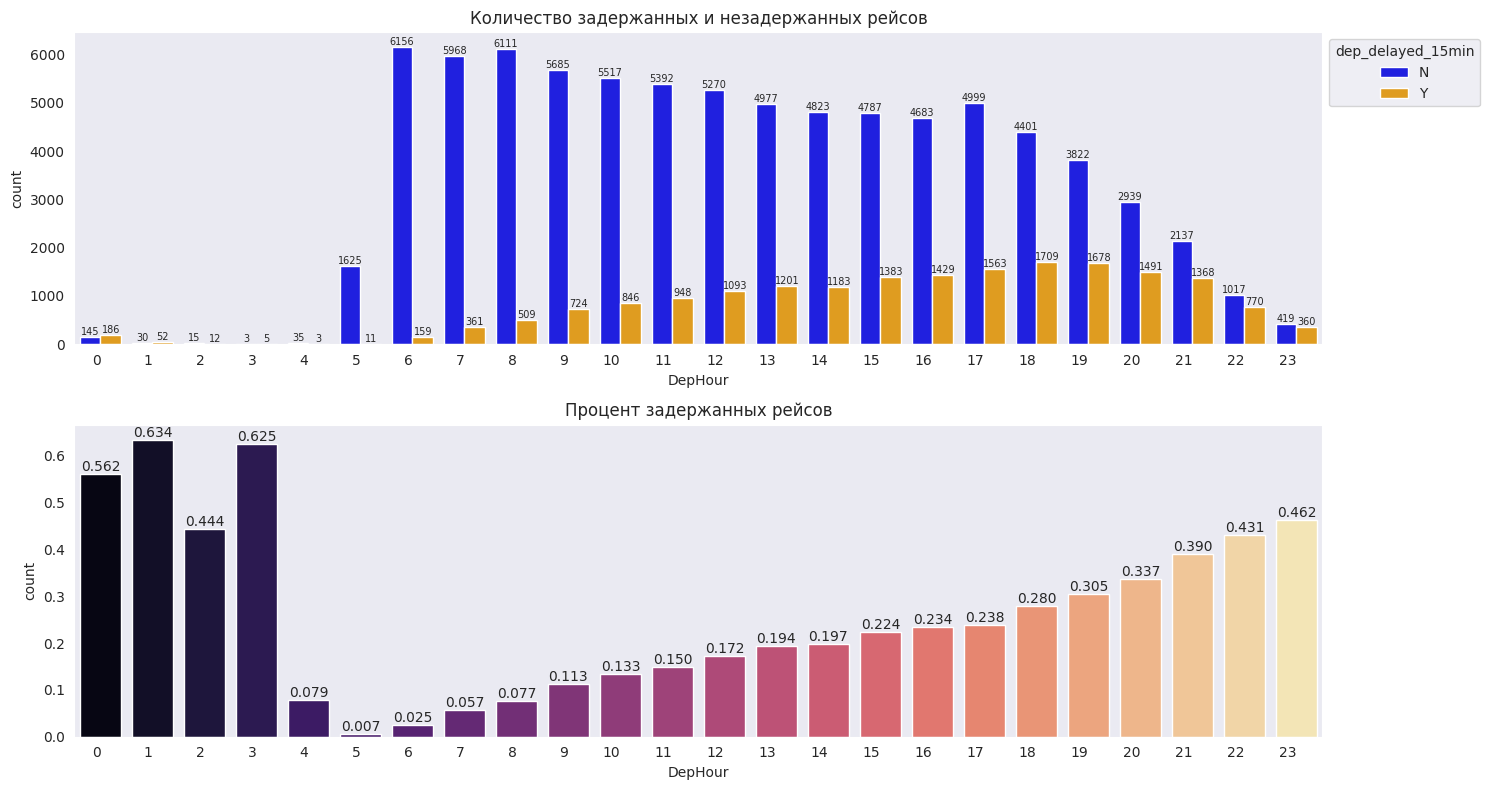

In [ ]:
plot_histograms('DepHour', fontsize=7)

Видим следующее: процент задержанных рейсов высок до 5 часов, а затем он плавно возрастает. С количеством же задержанных рейсов картина похожая 0 до 5 часов оно мало, плавно растёт до 19 часов, затем плавно снижается

Видим, что это важный признак, его следует оставить

Далее, если рассуждать логически, то важны могут быть следующие пары признаков:
- Комбинация перевозчика и пункта отправления
- Комбинация перевозчика и пункта прибытия
- Комбинация перевозчика и часа отправления
- Комбинация перевозичка и маршрута
- Комбинация маршрута и часа отправления
- Комбинация пункта и часа отправления
- Комбинация пункта прибытия и часа отправления

Следует добавить эти признаки в датасет

In [ ]:
for df in train, test:
    for column in ['Route', 'Dest', 'Origin', 'DepHour']:
        df.insert(test.shape[1], f'UniqueCarrier - {column}', df['UniqueCarrier'] + ' - ' + df[column].astype(str))
    for column in ['Route', 'Dest', 'Origin']:
        df.insert(test.shape[1], f'{column} - DepHour', df[column] + ' - ' + df['DepHour'].astype(str))

In [ ]:
train

,Month,DayOfMonth,DayOfWeek,DepTime,DepHour,UniqueCarrier,Origin,OriginCat,Dest,DestCat,Distance,Route,Origin - DepHour,Dest - DepHour,Route - DepHour,UniqueCarrier - DepHour,UniqueCarrier - Origin,UniqueCarrier - Dest,UniqueCarrier - Route,dep_delayed_15min
0,c-8,c-21,c-7,1934,19,AA,ATL,5,DFW,5,732,ATL - DFW,ATL - 19,DFW - 19,ATL - DFW - 19,AA - 19,AA - ATL,AA - DFW,AA - ATL - DFW,N
1,c-4,c-20,c-3,1548,15,US,PIT,4,MCO,5,834,PIT - MCO,PIT - 15,MCO - 15,PIT - MCO - 15,US - 15,US - PIT,US - MCO,US - PIT - MCO,N
2,c-9,c-2,c-5,1422,14,XE,RDU,4,CLE,4,416,RDU - CLE,RDU - 14,CLE - 14,RDU - CLE - 14,XE - 14,XE - RDU,XE - CLE,XE - RDU - CLE,N
3,c-11,c-25,c-6,1015,10,OO,DEN,5,MEM,4,872,DEN - MEM,DEN - 10,MEM - 10,DEN - MEM - 10,OO - 10,OO - DEN,OO - MEM,OO - DEN - MEM,N
4,c-10,c-7,c-6,1828,18,WN,MDW,4,OMA,3,423,MDW - OMA,MDW - 18,OMA - 18,MDW - OMA - 18,WN - 18,WN - MDW,WN - OMA,WN - MDW - OMA,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,c-5,c-4,c-3,1618,16,OO,SFO,5,RDD,1,199,SFO - RDD,SFO - 16,RDD - 16,SFO - RDD - 16,OO - 16,OO - SFO,OO - RDD,OO - SFO - RDD,N
99996,c-1,c-18,c-3,804,8,CO,EWR,5,DAB,2,884,EWR - DAB,EWR - 8,DAB - 8,EWR - DAB - 8,CO - 8,CO - EWR,CO - DAB,CO - EWR - DAB,N
99997,c-1,c-24,c-2,1901,19,NW,DTW,5,IAH,5,1076,DTW - IAH,DTW - 19,IAH - 19,DTW - IAH - 19,NW - 19,NW - DTW,NW - IAH,NW - DTW - IAH,N
99998,c-4,c-27,c-4,1515,15,MQ,DFW,5,GGG,1,140,DFW - GGG,DFW - 15,GGG - 15,DFW - GGG - 15,MQ - 15,MQ - DFW,MQ - GGG,MQ - DFW - GGG,N


Теперь посчитаем процент задержанных рейсов для тренировочной выборки, рассчитывая кумулятивную статистику для интервалов ([0-0.1), [0.1-0.2), ..., [0.9, 1])

/tmp/ipython-input-3547625900.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  percentage_delayed = dict(train.groupby('Route').apply(lambda x: x[x['dep_delayed_15min'] == 'Y'].shape[0] / x.shape[0]).sort_values(ascending=False))


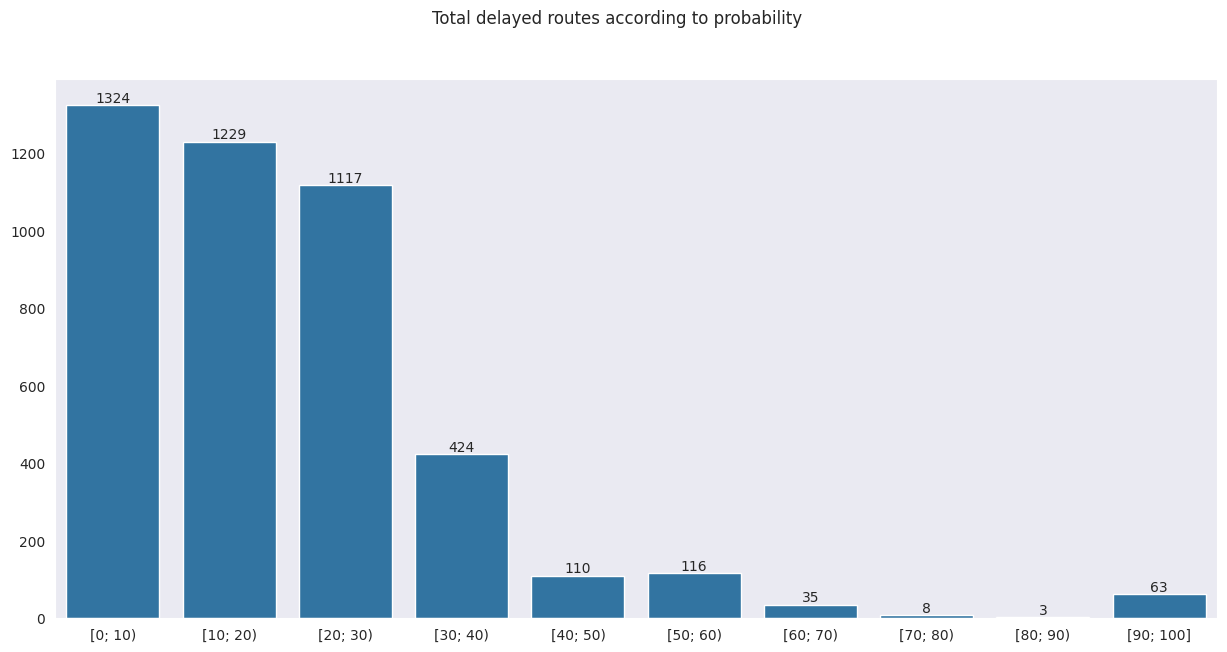

In [ ]:
percentage_delayed = dict(train.groupby('Route').apply(lambda x: x[x['dep_delayed_15min'] == 'Y'].shape[0] / x.shape[0]).sort_values(ascending=False))

intervals = {i * 10: 0 for i in range(10)}
for route, percent in percentage_delayed.items():
    key = int(percent * 100) // 10 * 10
    if key == 100:
        key -= 10
    intervals[key] += 1

_, ax = plt.subplots(figsize=(15, 7))

boxes, total = list(zip(*intervals.items()))
boxes = [f'[{box}; {box + 10}' + (')' if box < 90 else ']') for box in boxes]
sns.barplot(x=boxes, y=total, ax=ax)
ax.bar_label(ax.containers[0], fontsize=10)

plt.suptitle('Total delayed routes according to probability')
plt.show()

Видим, что в данном случае распределение напоминает экспоненциальное, и нечасто задерживаемых рейсов на порядок больше, чем часто задерживаемых

Видим, что около 3.75% тестовых маршрутов нет в тренировочных данных, поэтому при выборе модели стоит подбирать такие, чтобы не возникало проблем с новыми категориями

In [ ]:
test[~test['Route'].isin(percentage_delayed)].shape[0] / test.shape[0] * 100

3.749

Рассчитаем тоже самое и для остальных новых признаков

In [ ]:
for column in [
    'UniqueCarrier - Origin', 'UniqueCarrier - Dest', 'UniqueCarrier - DepHour',
    'UniqueCarrier - Route', 'Route - DepHour', 'Origin - DepHour', 'Dest - DepHour'
]:
    print(f'{column}: {test[~test[column].isin(train[column].unique())].shape[0] / test.shape[0] * 100}')

UniqueCarrier - Origin: 4.568
UniqueCarrier - Dest: 4.515000000000001
UniqueCarrier - DepHour: 3.4819999999999998
UniqueCarrier - Route: 7.568
Route - DepHour: 21.308
Origin - DepHour: 1.011
Dest - DepHour: 1.0699999999999998


Видим, что в основном, процент не превышает 7.6б единственное исключение - комбинация маршрута и часа отправления, там более 21% тестовых данных не пристутвует в тренировочных

Добавим следующие признаки для исходного датасета - широту и долготу аэропорта, для этого скачаем датасет с аэропортами

In [ ]:
airports = pd.read_csv('airports.csv')
airports.head()

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


Для тех аэропортов, которые обслуживают несколько городов, оставим только первый из них

In [ ]:
airports[airports['CITY'].str.contains('/')]

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
7,ACV,Arcata Airport,Arcata/Eureka,CA,USA,40.97812,-124.10862
24,AVP,Wilkes-Barre/Scranton International Airport,Wilkes-Barre/Scranton,PA,USA,41.33815,-75.72427
40,BPT,Jack Brooks Regional Airport (Southeast Texas ...,Beaumont/Port Arthur,TX,USA,29.95083,-94.02069
68,CMI,University of Illinois - Willard Airport,Champaign/Urbana,IL,USA,40.03925,-88.27806
156,IMT,Ford Airport,Iron Mountain/Kingsford,MI,USA,45.81835,-88.11454
170,KOA,Kona International Airport at Keahole,Kailua/Kona,HI,USA,19.73877,-156.04563
319,XNA,Northwest Arkansas Regional Airport,Fayetteville/Springdale/Rogers,AR,USA,36.28187,-94.30681


In [ ]:
airports.loc[airports['CITY'].str.contains('/'), 'CITY'] = airports[airports['CITY'].str.contains('/')]['CITY'].apply(lambda s: s[:s.find('/')])

Также разделителями бывают ещё и тире, здесь нужно также осавить первые города за исключением Wilkes-Bare, так как это один город

In [ ]:
airports[airports['CITY'].str.contains('-')]

,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
24,AVP,Wilkes-Barre/Scranton International Airport,Wilkes-Barre,PA,USA,41.33815,-75.72427
86,DFW,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,USA,32.89595,-97.03720
126,GPT,Gulfport-Biloxi International Airport,Gulfport-Biloxi,MS,USA,30.40728,-89.07009
135,GTR,Golden Triangle Regional Airport,Columbus-Starkville-West Point,MS,USA,33.45033,-88.59137
241,PIB,Hattiesburg-Laurel Regional Airport,Hattiesburg-Laurel,MS,USA,31.46715,-89.33706


In [ ]:
airports.loc[(airports['CITY'].str.contains('-')) & (airports['CITY'] != 'Wilkes-Barre'), 'CITY'] = \
    airports[(airports['CITY'].str.contains('-')) & (airports['CITY'] != 'Wilkes-Barre')]['CITY'].apply(lambda s: s[:s.find('-')])

Составим словари для добавления признаков города, штата, широты и долготы аэропортов убытия и прибытия

In [ ]:
cities_map = pd.Series(airports['CITY'].values, index=airports['IATA_CODE']).to_dict()
states_map = pd.Series(airports['STATE'].values, index=airports['IATA_CODE']).to_dict()
latitudes_map = pd.Series(airports['LATITUDE'].values, index=airports['IATA_CODE']).to_dict()
longitudes_map = pd.Series(airports['LONGITUDE'].values, index=airports['IATA_CODE']).to_dict()

Используем словари на практике

In [ ]:
for column in 'Origin', 'Dest':
    index = train.columns.get_loc(f'{column}Cat')
    for df in train, test:
        df.insert(index + 1, f'{column}City', df[column].apply(lambda x: cities_map.get(x, np.nan)))
        df.insert(index + 2, f'{column}State', df[column].apply(lambda x: states_map.get(x, np.nan)))
        df.insert(index + 3, f'{column}AirportLatitude', df[column].apply(lambda x: latitudes_map.get(x, np.nan)))
        df.insert(index + 4, f'{column}AirportLongitude', df[column].apply(lambda x: longitudes_map.get(x, np.nan)))

In [ ]:
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,DepHour,UniqueCarrier,Origin,OriginCat,OriginCity,OriginState,...,Distance,Route,Origin - DepHour,Dest - DepHour,Route - DepHour,UniqueCarrier - DepHour,UniqueCarrier - Origin,UniqueCarrier - Dest,UniqueCarrier - Route,dep_delayed_15min
0,c-8,c-21,c-7,1934,19,AA,ATL,5,Atlanta,GA,...,732,ATL - DFW,ATL - 19,DFW - 19,ATL - DFW - 19,AA - 19,AA - ATL,AA - DFW,AA - ATL - DFW,N
1,c-4,c-20,c-3,1548,15,US,PIT,4,Pittsburgh,PA,...,834,PIT - MCO,PIT - 15,MCO - 15,PIT - MCO - 15,US - 15,US - PIT,US - MCO,US - PIT - MCO,N
2,c-9,c-2,c-5,1422,14,XE,RDU,4,Raleigh,NC,...,416,RDU - CLE,RDU - 14,CLE - 14,RDU - CLE - 14,XE - 14,XE - RDU,XE - CLE,XE - RDU - CLE,N
3,c-11,c-25,c-6,1015,10,OO,DEN,5,Denver,CO,...,872,DEN - MEM,DEN - 10,MEM - 10,DEN - MEM - 10,OO - 10,OO - DEN,OO - MEM,OO - DEN - MEM,N
4,c-10,c-7,c-6,1828,18,WN,MDW,4,Chicago,IL,...,423,MDW - OMA,MDW - 18,OMA - 18,MDW - OMA - 18,WN - 18,WN - MDW,WN - OMA,WN - MDW - OMA,Y


Теперь добавим численность населения и штат для города убытия и прибытия, для этого нужно скачать датасет с городами

In [ ]:
cities = pd.read_excel('uscities.xlsx')
cities.head()

,city,city_ascii,state_id,state_name,county_fips,county_name,lat,lng,population,density,source,military,incorporated,timezone,ranking,zips,id
0,New York,New York,NY,New York,36081,Queens,40.6943,-73.9249,18832416,10943.7,shape,False,True,America/New_York,1,11229 11228 11226 11225 11224 11222 11221 1122...,1840034016
1,Los Angeles,Los Angeles,CA,California,6037,Los Angeles,34.1141,-118.4068,11885717,3165.7,shape,False,True,America/Los_Angeles,1,91367 90291 90293 90292 91316 91311 90035 9003...,1840020491
2,Chicago,Chicago,IL,Illinois,17031,Cook,41.8375,-87.6866,8489066,4590.3,shape,False,True,America/Chicago,1,60018 60649 60641 60640 60643 60642 60645 6064...,1840000494
3,Miami,Miami,FL,Florida,12086,Miami-Dade,25.7840,-80.2101,6113982,4791.1,shape,False,True,America/New_York,1,33128 33129 33125 33126 33127 33149 33144 3314...,1840015149
4,Houston,Houston,TX,Texas,48201,Harris,29.7860,-95.3885,6046392,1386.2,shape,False,True,America/Chicago,1,77069 77068 77061 77060 77063 77062 77065 7706...,1840020925


Составим словари замен для населения и штатов. Следует отметить, что бывают города с одинаковыми названиями, поэтому временно можно создать новый признак, который скливает название города и сокращение штата, таким образом однозначно определяя город

In [ ]:
cities = cities.assign(city_state=cities['city_ascii'] + '_' + cities['state_id'])
states_map = pd.Series(cities['state_name'].values, index=cities['city_state']).to_dict()
population_map = pd.Series(cities['population'].values, index=cities['city_state']).to_dict()

Снова используем словари на практике

In [ ]:
for column in 'Origin', 'Dest':
    index = train.columns.get_loc(f'{column}City')
    for df in train, test:
        df.insert(index + 1, f'{column}CityPopulation', df.assign(city_state=df[f'{column}City'] + '_' + df[f'{column}State'])['city_state'].apply(lambda x: population_map.get(x, np.nan)))
        df.insert(index + 2, f'{column}CityState', df.assign(city_state=df[f'{column}City'] + '_' + df[f'{column}State'])['city_state'].apply(lambda x: states_map.get(x, np.nan)))

Теперь удалим названия с сокращениями штатов, так как они больше не нужны

In [ ]:
train = train.drop(columns=['OriginState', 'DestState'])
test = test.drop(columns=['OriginState', 'DestState'])

In [ ]:
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,DepHour,UniqueCarrier,Origin,OriginCat,OriginCity,OriginCityPopulation,...,Distance,Route,Origin - DepHour,Dest - DepHour,Route - DepHour,UniqueCarrier - DepHour,UniqueCarrier - Origin,UniqueCarrier - Dest,UniqueCarrier - Route,dep_delayed_15min
0,c-8,c-21,c-7,1934,19,AA,ATL,5,Atlanta,5211164.0,...,732,ATL - DFW,ATL - 19,DFW - 19,ATL - DFW - 19,AA - 19,AA - ATL,AA - DFW,AA - ATL - DFW,N
1,c-4,c-20,c-3,1548,15,US,PIT,4,Pittsburgh,1712828.0,...,834,PIT - MCO,PIT - 15,MCO - 15,PIT - MCO - 15,US - 15,US - PIT,US - MCO,US - PIT - MCO,N
2,c-9,c-2,c-5,1422,14,XE,RDU,4,Raleigh,1150010.0,...,416,RDU - CLE,RDU - 14,CLE - 14,RDU - CLE - 14,XE - 14,XE - RDU,XE - CLE,XE - RDU - CLE,N
3,c-11,c-25,c-6,1015,10,OO,DEN,5,Denver,2691349.0,...,872,DEN - MEM,DEN - 10,MEM - 10,DEN - MEM - 10,OO - 10,OO - DEN,OO - MEM,OO - DEN - MEM,N
4,c-10,c-7,c-6,1828,18,WN,MDW,4,Chicago,8489066.0,...,423,MDW - OMA,MDW - 18,OMA - 18,MDW - OMA - 18,WN - 18,WN - MDW,WN - OMA,WN - MDW - OMA,Y


К сожалению, в таблице аэропортов содержались не все аэропорты, которые есть в тренировочных и тестовых данных, поэтому необходимо будет самостоятельно вручную заполнить недостающие данные

Для начала надо составть словарь замен, в котором ключами будут служить коды аэропортов, а значениями - списки из 5 элементов, состоящие из названия города, населения города, штата, в котором находится город, а также широты и долготы соответосвующего городу аэропорта

In [ ]:
missed_airports_map = {
    'APF': ['Naples', 322000.0, 'Florida', 26.15250, -81.77555],
    'CIC': ['Chico', 211632.0, 'California', 39.79528, -121.85833],
    'FLO': ['Florence', 199630.0, 'South Carolina', 34.18528, -79.72389],
    'HHH': ['Hilton Head Island', 232523.0, 'South Carolina', 32.22444, -80.69750],
    'HKY': ['Hickory', 368347.0, 'North Carolina', 35.74111, -81.38944],
    'HTS': ['Huntington', 368261.0, 'West Virginia', 38.36694, -82.55861],
    'HVN': ['New Haven', 576718.0, 'Connecticut', 41.26389, -72.88667],
    'IPL': ['Imperial', 175000.0, 'California', 32.83417, -115.57861],
    'ISO': ['Kingston', 19900.0, 'North Carolina', 35.33139, -77.60889],
    'IYK': ['Bakersfield', 909235.0, 'California', 35.65861, -117.82944],
    'LWB': ['Lewisburg', 3930.0, 'West Virginia', 37.85833, -80.39944],
    'LYH': ['Lynchburg', 261593.0, 'Virginia', 37.32528, -79.20111],
    'MCN': ['Macon', 233802.0, 'Georgia', 32.69278, -83.64917],
    'MOD': ['Modesto', 552878.0, 'California', 37.62583, -120.95444],
    'MTH': ['Marathon', 9689.0, 'Florida', 24.72611, -81.05139],
    'OXR': ['Oxnard', 843843.0, 'California', 31.20083, -119.20722],
    'PFN': ['Panama City', 202236.0, 'Florida', 30.21222, -85.68278],
    'PIE': ['St. Petersburg', 2870569.0, 'Florida', 27.91000, -82.68750],
    'PMD': ['Palmdale', 359559.0, 'California', 34.62861, -118.08444],
    'RFD': ['Rockford', 276443.0, 'Illinois', 42.19528, -89.09722],
    'SLE': ['Salem', 268331.0, 'Oregon', 44.90944, -123.00250],
    'SOP': ['Southern Pines', 50319.0, 'North Carolina', 35.23722, -79.39111],
    'TEX': ['Telluride', 2607.0, 'Colorado', 37.95389, -107.90861],
    'TUP': ['Tupelo', 37923.0, 'Mississippi', 34.26806, -88.77000],
    'VCT': ['Victoria', 65534.0, 'Texas', 28.85250, -96.91861],
    'VIS': ['Visalia', 141384.0, 'California', 36.31861, -119.39278],
    'YKM': ['Yakima', 96968.0, 'Washington', 46.56806, -120.54417]
}

Применим словарь для замен

In [ ]:
for column in 'Origin', 'Dest':
    for df in train, test:
        df.loc[df[f'{column}City'].isna(), [f'{column}City', f'{column}CityPopulation', f'{column}CityState', f'{column}AirportLatitude', f'{column}AirportLongitude']] = \
            df[df[f'{column}City'].isna()][column].apply(lambda x: missed_airports_map.get(x, None)).to_list()

Также существуют записи, где неизвестны население и штат для города, это тоже придётся править вручную

Надо создать словарь, где ключами будут города, а значениями - списки, состоящие из 2 значний - населения города и штата

In [ ]:
missed_cities_map = {
    'Barrow': [4927.0, 'Alaska'],
    'Charlotte Amalie': [18481.0, 'Virginian Islands'],
    'Christiansted': [1866.0, 'Virginian Islands'],
    'Deadhorse': [25.0, 'Deadhorse'],
    'Ft. Lauderdale': [183146.0, 'Florida'],
    'Ft. Myers': [95949.0, 'Florida'],
    'Islip': [339938.0, 'New York'],
    'Nantucket': [14255.0, 'Massachusetts'],
    'Newburgh': [28259.0, 'New York'],
    'St George': [78505.0, 'Utah'],
    'St Louis': [279695.0, 'Missouri'],
    'Windsor Locks': [12613.0, 'Connecticut']
}

Применим словарь для замен

In [ ]:
for column in 'Origin', 'Dest':
    for df in train, test:
        df.loc[df[f'{column}CityState'].isna(), [f'{column}CityPopulation', f'{column}CityState']] = \
            df[df[f'{column}CityState'].isna()][f'{column}City'].apply(lambda x: missed_cities_map.get(x, None)).to_list()

Посмотрим на статистку задержанных рейсов в зависимости от штата отправления

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


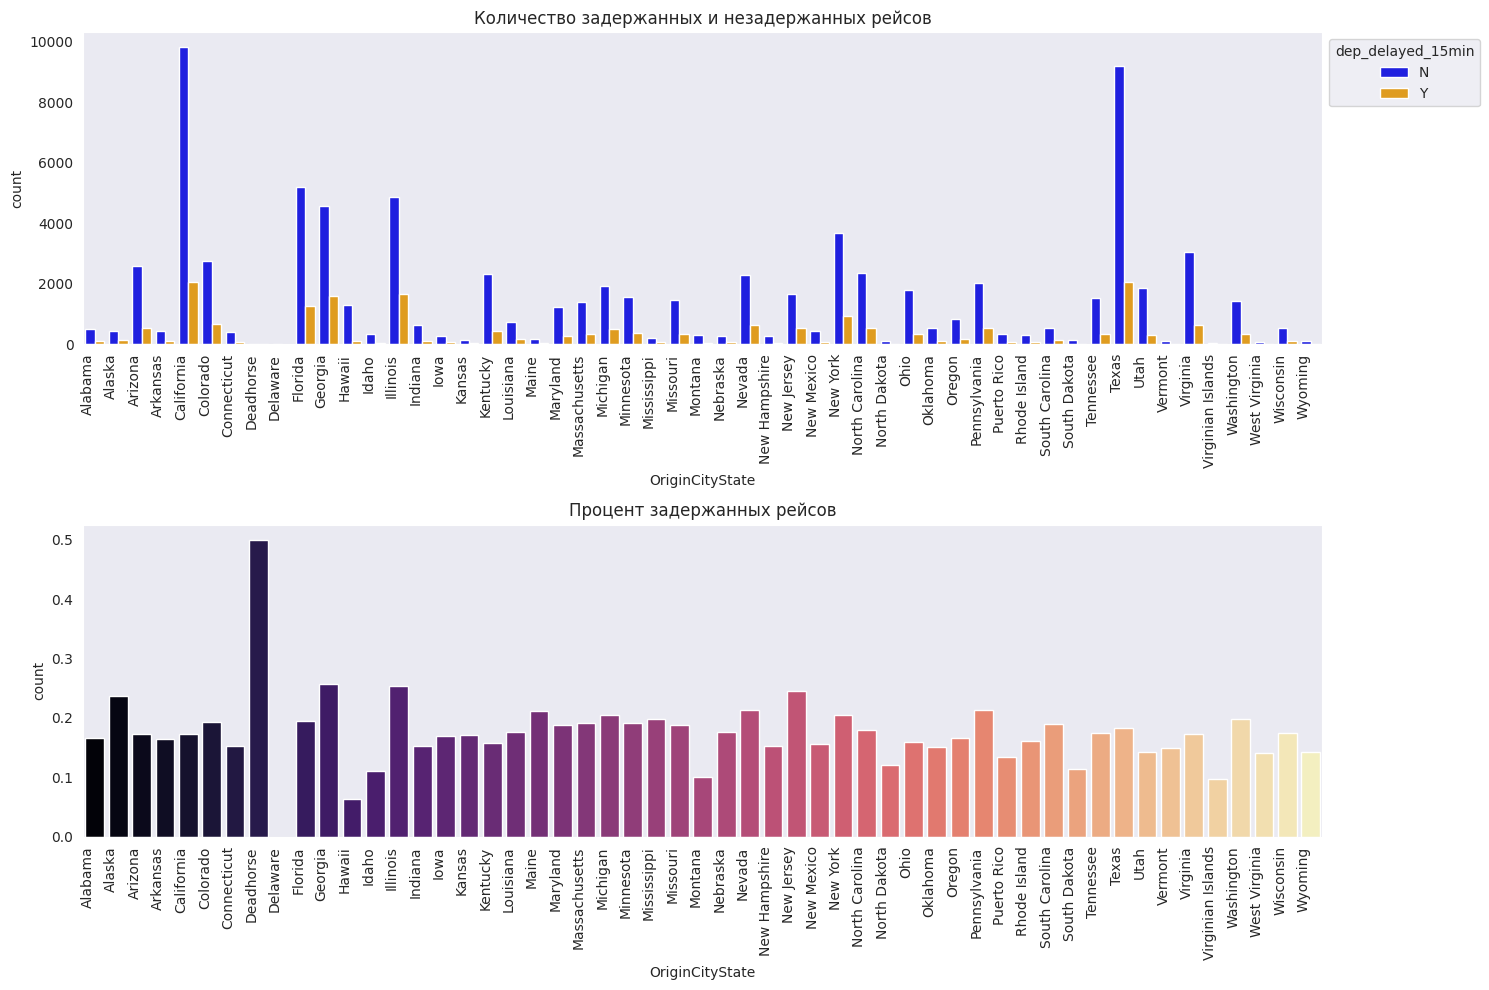

In [ ]:
plot_histograms('OriginCityState', rotation=90, figsize=(15, 10), plotbars=False)

Видим, что количественно больше всего рейсов задерживаются при отправке из таких штатов как Калифорния, Джорджия, Иллинойс и Техас. В процентном же отошении "лидерами"  являются Аляска, Джорджия, Иллинойс и Нью-Джерси

При этом в таких штатах как Коннектикут и Делавэр, задержанных рейсов нет вообще, впрочем и отправленных там почти нет

Теперь проделаем тоже самое с прибывшими рейсами

/tmp/ipython-input-1491458951.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=rotation, ha='right')
/tmp/ipython-input-1491458951.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1491458951.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=rotation, ha='right')


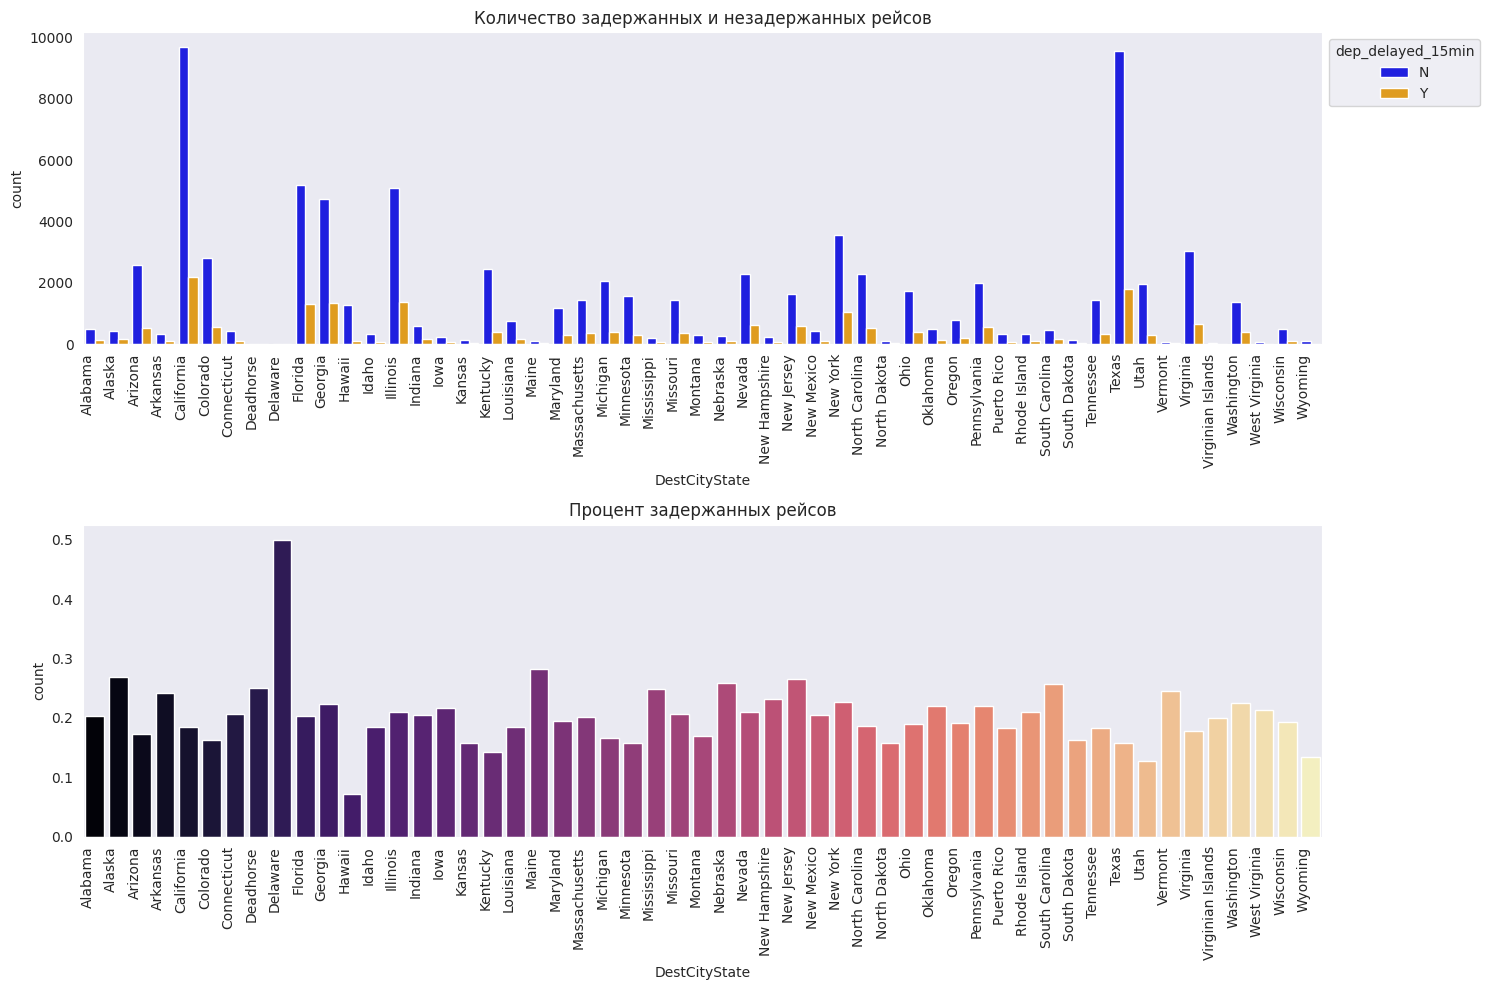

In [ ]:
plot_histograms('DestCityState', rotation=90, figsize=(15, 10), plotbars=False)

По проценту задержанных рейсов из штатов отправления "лидерами" по-пежнему являютя такие штаты, как Калифорния, Джорджия, Иллинойс и Техас. А вот штатами, в которые рейсы задерживаются чаще всего, в процентном отношении, являются Коннектикут, Делавэр и Мэн

 Теперь посмотрим на плотноти распределения населения города убытия и населения города прибытия в зависимости от того, был задержан рейс или нет

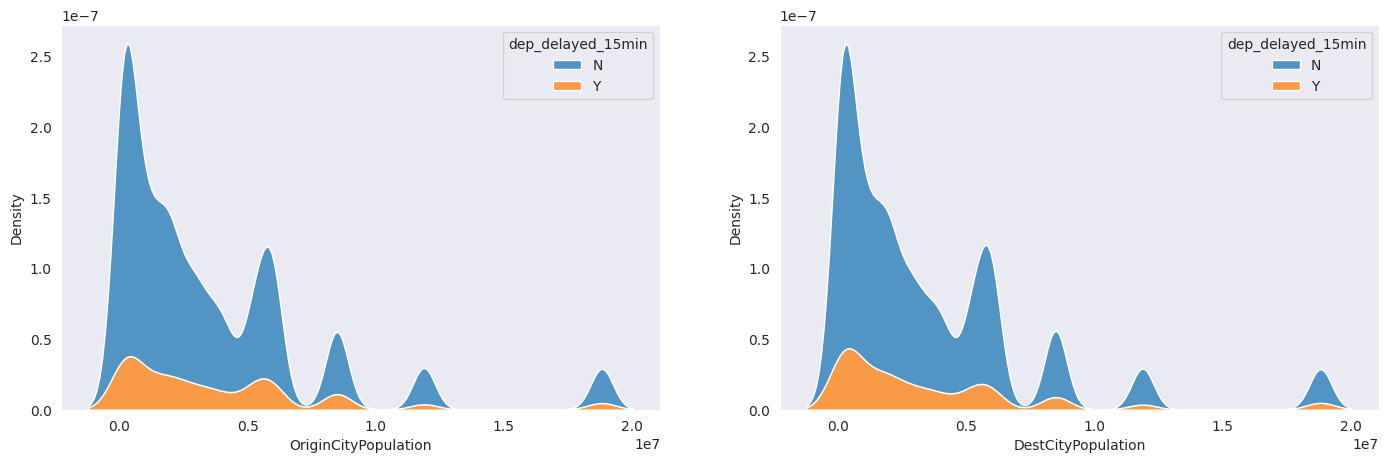

In [ ]:
_, ax = plt.subplots(nrows=1, ncols=2, figsize=(17, 5))
sns.kdeplot(data=train, x='OriginCityPopulation', hue='dep_delayed_15min', multiple='stack', ax=ax[0])
sns.kdeplot(data=train, x='DestCityPopulation', hue='dep_delayed_15min', multiple='stack', ax=ax[1])
plt.show()

Видим, что формы распределения для тренировочных данных совпадают для обоих графиков, как и для тестовых. Пики у распределений находятся в тех же местах

Зачастую одному городу соотвествует один аэропорт, поэтому, чтобы уменьшить количество признаков, удалим столбцы с названиями городов убытия и прибытия

In [ ]:
city_columns = ['OriginCity', 'DestCity']
train = train.drop(columns=city_columns)
test = test.drop(columns=city_columns)

Перведём столбцы месяца, дня месяца и дня недели в числовые

In [ ]:
time_columns = ['Month', 'DayOfMonth', 'DayOfWeek']
for column in time_columns:
    for df in train, test:
        df[column] = df[column].str[2:].astype(int)

Сделаем то, что по-хорошему надо было сделать уже очень давно - заменить значения Y и N в целевой переменной на 1 и 0

In [ ]:
train['dep_delayed_15min'] = train['dep_delayed_15min'].replace({'N': 0, 'Y': 1}).astype(int)
train.head()

,Month,DayOfMonth,DayOfWeek,DepTime,DepHour,UniqueCarrier,Origin,OriginCat,OriginCityPopulation,OriginCityState,...,Distance,Route,Origin - DepHour,Dest - DepHour,Route - DepHour,UniqueCarrier - DepHour,UniqueCarrier - Origin,UniqueCarrier - Dest,UniqueCarrier - Route,dep_delayed_15min
0,8,21,7,1934,19,AA,ATL,5,5211164.0,Georgia,...,732,ATL - DFW,ATL - 19,DFW - 19,ATL - DFW - 19,AA - 19,AA - ATL,AA - DFW,AA - ATL - DFW,0
1,4,20,3,1548,15,US,PIT,4,1712828.0,Pennsylvania,...,834,PIT - MCO,PIT - 15,MCO - 15,PIT - MCO - 15,US - 15,US - PIT,US - MCO,US - PIT - MCO,0
2,9,2,5,1422,14,XE,RDU,4,1150010.0,North Carolina,...,416,RDU - CLE,RDU - 14,CLE - 14,RDU - CLE - 14,XE - 14,XE - RDU,XE - CLE,XE - RDU - CLE,0
3,11,25,6,1015,10,OO,DEN,5,2691349.0,Colorado,...,872,DEN - MEM,DEN - 10,MEM - 10,DEN - MEM - 10,OO - 10,OO - DEN,OO - MEM,OO - DEN - MEM,0
4,10,7,6,1828,18,WN,MDW,4,8489066.0,Illinois,...,423,MDW - OMA,MDW - 18,OMA - 18,MDW - OMA - 18,WN - 18,WN - MDW,WN - OMA,WN - MDW - OMA,1


Теперь найдём категориальные и численные столбцы

In [ ]:
categorical_columns = [column for column in train.columns if train[column].dtypes == 'O']
numerical_columns = [column for column in train.columns if train[column].dtypes != 'O']

Посчитаем корреляцию Пирсона по численным столбцам

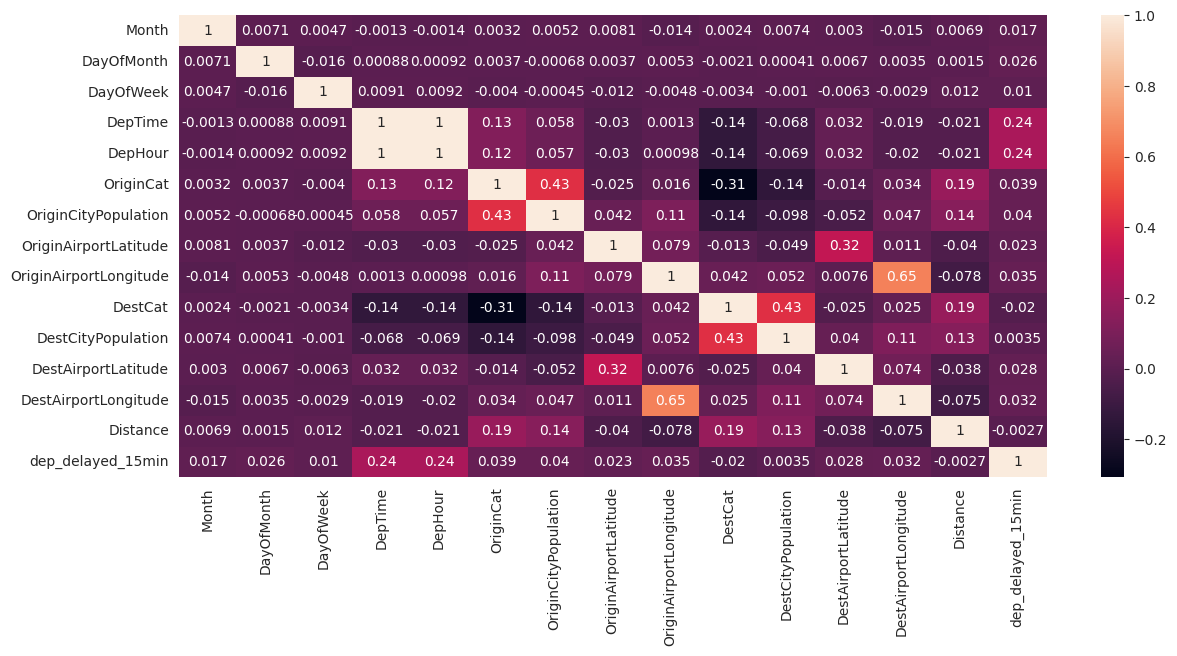

In [ ]:
_, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(train[numerical_columns].corr(), annot=True, ax=ax)
plt.show()

Делаем следующие выводы:
- С целевой переменной больше всего коррелируют признаки времени отправления и часа отправления
- Единичная корреляция между признаками времени и часа отправления (ну так и должно быть)
- Максимальная неединичная положительная корреляция между признаками долгот аэропортов убытия и прибытия
- Максимальная по модулю отрицательная корреляция между категориальными признаками пунктов убытия и прибытия
- Достаточно высокая положительная корреляция между парами численности населения города убытия и категориального признака пункта убытия. Тоже самое годится и для прибытия

При подсчёте используется коэффициент неопределённости Тейла (так как категориальная переменная сравнивается с категориальной)

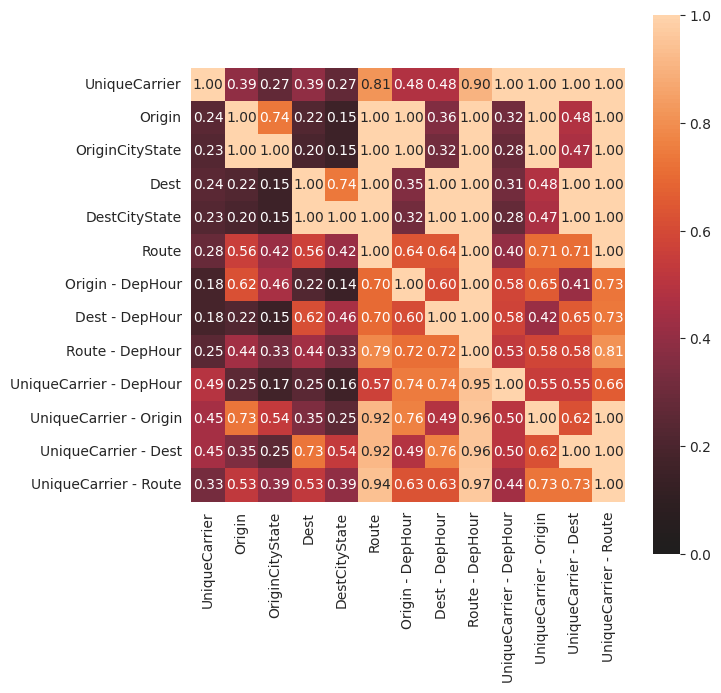

In [ ]:
categorical_correlation_matrix = associations(dataset=train[categorical_columns], compute_only=False, nom_nom_assoc='theil', figsize=(7, 7))

Видим следующее:
- Высокая корреляция между авиаперевозчиком и рейсом, что логично, ведь у перевозчика могут быть регулярные рейсы между конкретными аэропортами
- Единичные корреляции в основном у тех пар признаков, которые имеют что-то общее либо с маршрутом, либо с перевозчиком, либо с пунктами убытия и прибытия
- Также выоская корреляция между перевозчиком и комбинацией признаков маршрута и часа отправления


### Обучение модели

В данной работе я буду обучать CatBoost (я пробовал помимо него обучать также XGBoost и LightGBM, однако CatBoost показал наилучшие результаты). Для модели будут подобраны оптимальные гиперапарамеры с помощью фреймворка optuna на кросс-валидации таким образом, чтобы значение метрики roc_auc на валидационной выборке было как можно больше



Определим X_train, y_train и X_test

In [ ]:
X_train, y_train = train.drop(columns='dep_delayed_15min'), train['dep_delayed_15min']
X_test = test

Удалим из численных столбцов целевую переменную

In [ ]:
numerical_columns.remove('dep_delayed_15min')

Посчитаем веса для классов (так как датасет несбалансирован)

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

Создадим функцию, в которой будем подбирать оптимальные гиперпараметры с помощью OptunaSearchCV

In [ ]:
def search(estimator, distributions, n_trials, X_train=X_train, y_train=y_train):
    optuna_search = OptunaSearchCV(
        estimator=estimator,
        param_distributions=distributions,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_trials=n_trials, scoring='roc_auc',
        verbose=1
    )
    optuna_search.fit(X_train, y_train)
    return optuna_search

Начнём подбор гиперпараметров, они будут следующими:
- Количество решающих деревьев в ансамбле
- Максимальная глубина решающего дерева
- Темп обучения
- Квадратичная регуляризация в листе решающего дерева
- Минимальное количество объектов влисте решающего дерева

In [72]:
%%time
cb = CatBoostClassifier(
    loss_function='Logloss',
    class_weights=class_weights,
    cat_features=categorical_columns,
    verbose=0
)

cb_param_distributions = {
    'n_estimators': optuna.distributions.IntDistribution(50, 500, log=True),
    'depth': optuna.distributions.IntDistribution(2, 12),
    'learning_rate': optuna.distributions.FloatDistribution(1e-2, 1, log=True),
    'l2_leaf_reg': optuna.distributions.FloatDistribution(1e-2, 1, log=True),
    'min_data_in_leaf': optuna.distributions.IntDistribution(1, 50),
}

best_cb = search(cb, cb_param_distributions, 50)

/tmp/ipython-input-3864506637.py:2: ExperimentalWarning: OptunaSearchCV is experimental (supported from v0.17.0). The interface can change in the future.
  optuna_search = OptunaSearchCV(
[I 2025-08-08 15:46:49,148] A new study created in memory with name: no-name-be3c45fc-1805-4fa8-a9af-7fc06f541337
INFO:optuna_integration.sklearn.sklearn:Searching the best hyperparameters using 100000 samples...
[I 2025-08-08 15:48:12,917] Trial 0 finished with value: 0.7536442160791248 and parameters: {'n_estimators': 151, 'depth': 6, 'learning_rate': 0.034256513808363385, 'l2_leaf_reg': 0.12286658353695418, 'min_data_in_leaf': 49}. Best is trial 0 with value: 0.7536442160791248.
[I 2025-08-08 15:57:34,454] Trial 1 finished with value: 0.7622152177578684 and parameters: {'n_estimators': 267, 'depth': 8, 'learning_rate': 0.02007312442821537, 'l2_leaf_reg': 0.04397295681945699, 'min_data_in_leaf': 10}. Best is trial 1 with value: 0.7622152177578684.
[I 2025-08-08 16:17:17,397] Trial 2 finished with va

CPU times: user 10h 11min 29s, sys: 33min 43s, total: 10h 45min 12s
Wall time: 6h 10min 42s


Создадим переменную explainer и посчитаем значения SHAP для всей выборки

In [73]:
explainer_cb = shap.TreeExplainer(best_cb.best_estimator_)
shap_values_cb = explainer_cb.shap_values(X_train)

Посмотрим на важности признаков по значениям SHAP

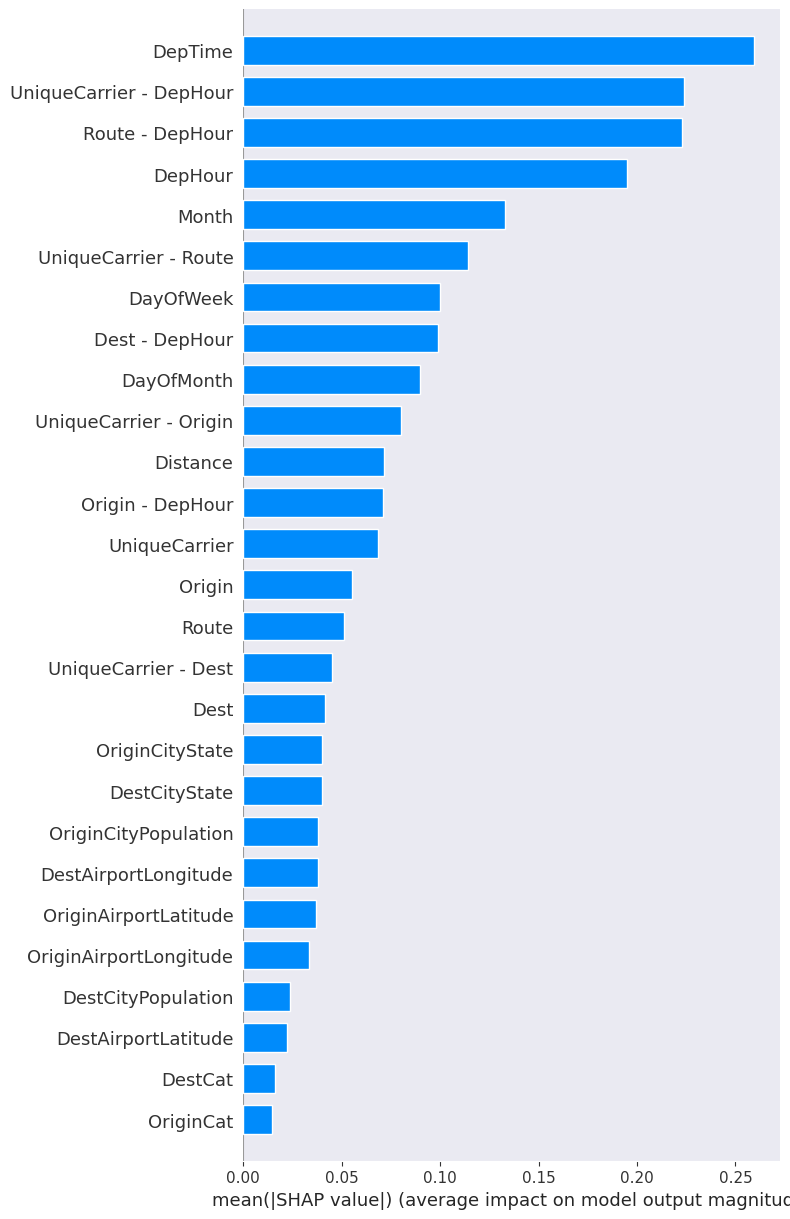

In [74]:
shap.summary_plot(shap_values_cb, X_train, plot_type='bar', max_display=test.shape[1])

Выводы:
- Самый важный признак с точки зрения SHAP - время отправления
- Самый важный "склеенный" признак - комбинация маршрута и часа отправления
- "Склеенные" признаки в основном оказались довольно важными
- Новые признаки из других датасетов оказались скорее неважными, чем важными
- Каждый признак оказался хоть сколько-нибудь важным

Затем посмотрим на важность влияния каждого признака на формирование ответов из всей обучающей выборки

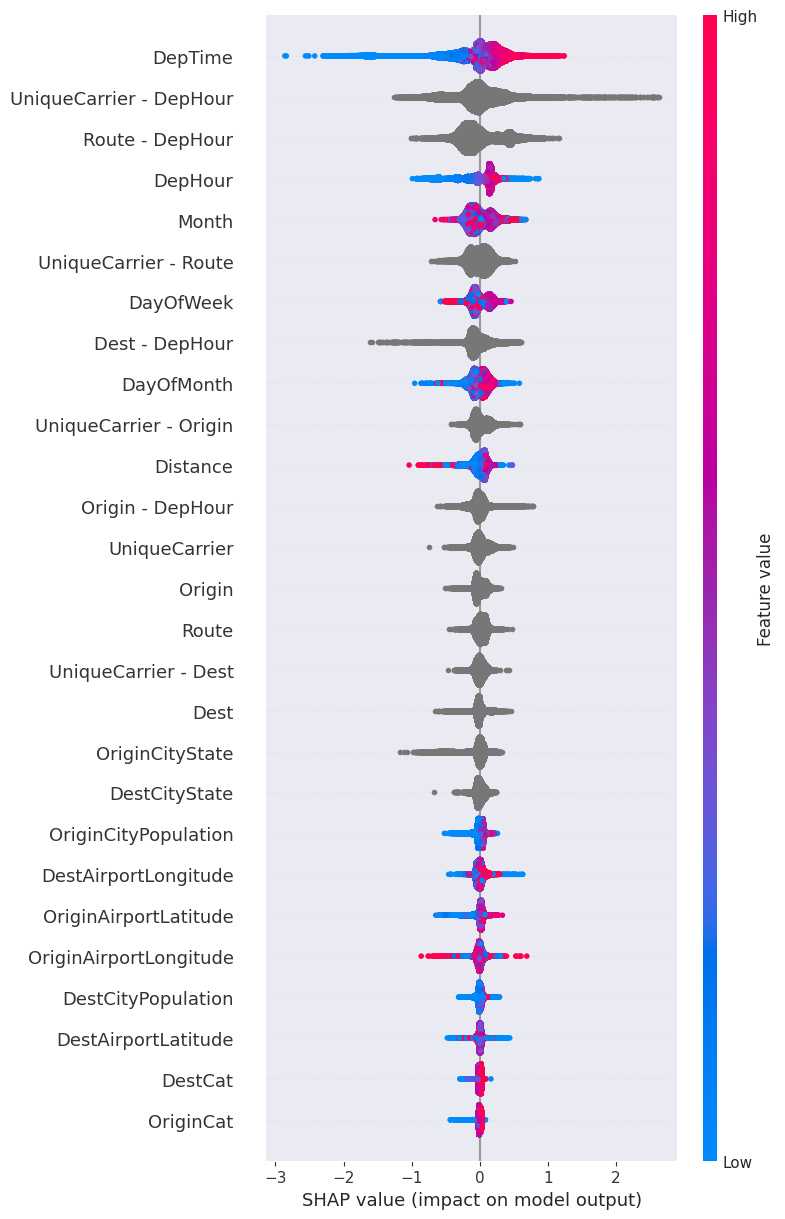

In [75]:
shap.summary_plot(shap_values_cb, X_train, max_display=test.shape[1])

Выводы:
- Для признака времени отправления можно с уверенностью сказать, что меньшие значения сответствуют меньшей вероятности задержки рейса. Тоже самое в большей степени касается, как это ни странно, долготы аэропорта убытия
- У признака часа отправления всё перемешано и нельзя точно сказать о корреляции величины значения и вероятности задержки рейса
- Также всё перемешано и у признака месяца, для него верны те же выводы, что и для предыдущего пункта

Сделаем предсказание

In [76]:
preds = pd.Series(best_cb.best_estimator_.predict_proba(X_test)[:, 1], index=X_test.index, name='dep_delayed_15min')
preds.index.name = 'id'
preds.to_csv('submission.csv')

Результат на Kaggle
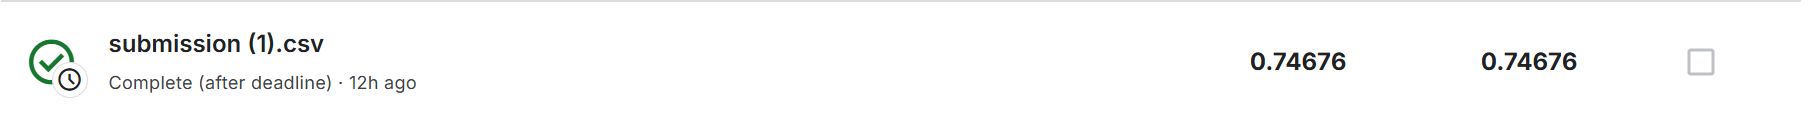